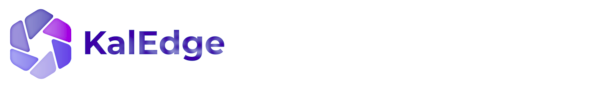

---

# HyperFPGA: Inference test

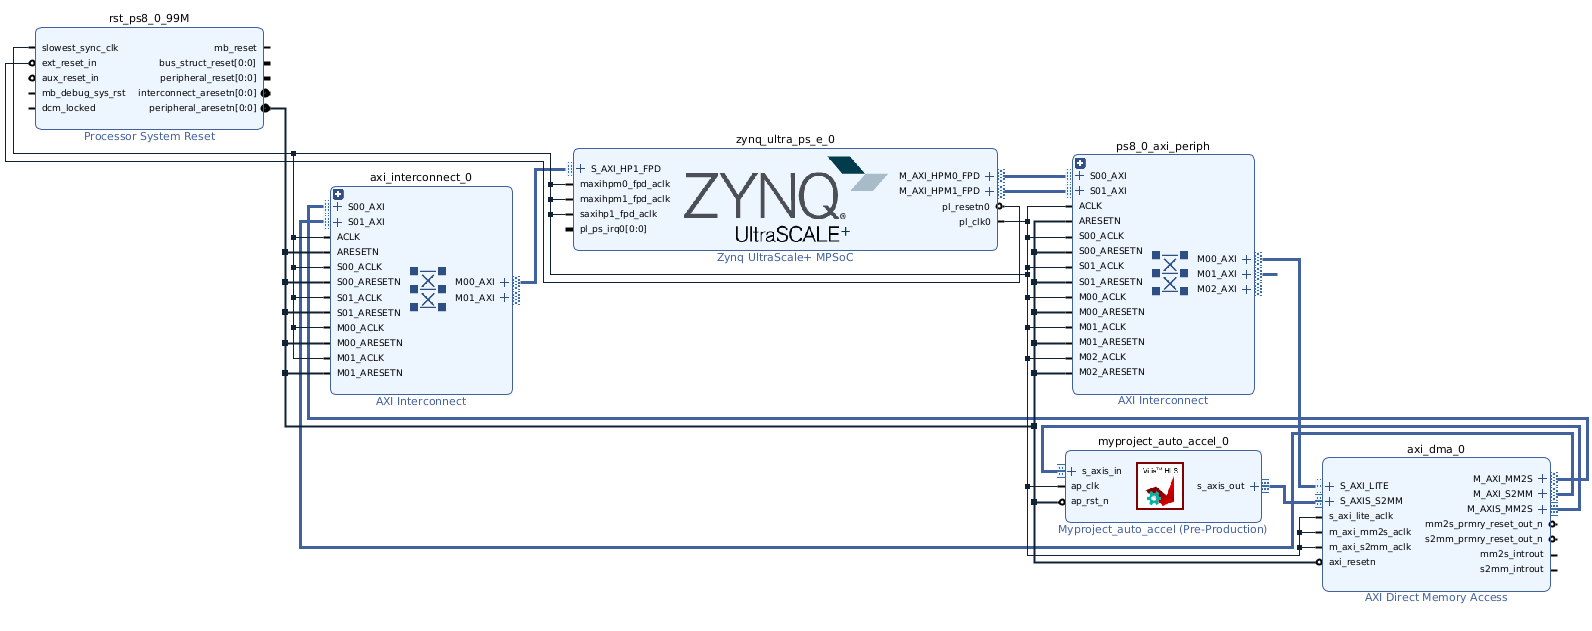

## 0. Setup: eligible nodes and target node

In [1]:
import math
import os

import numpy as np
import hyperfpga_cluster as hfc
from hyperfpga_cluster import configure_logging
configure_logging()

print(hfc.available_models())
test_nodes = await hfc.request_nodes('4ge21')
print(test_nodes[0]['fpga'])

{'4ge21': 9, '3be11': 9}
{'model': '4ge21', 'state': 'unknown', 'firmware': ''}


## 1. FPGA inference - AXI DMA

### Load dataset

In [2]:
import pandas as pd
import numpy as np

# Load dataset
csv_file = 'Npulsos_saturados_balanced_1200.csv'
df = pd.read_csv(csv_file)

# Class filtering - Only class 0 and 1
df = df[df['class'].isin([0, 1])]

print("Filtered dataset - Preview:")
print(df.head())

labels = df['class']
pulses = df.drop(columns=['class'])

y_true = labels.to_numpy()
x_pulses = pulses.to_numpy().astype(np.float32)

print(f"Input shape (filtered): {x_pulses.shape}")
print(f"Label shape (filtered): {y_true.shape}")

# "per-sample" normalization - range [-1, 1] - Based on KalEdge
min_vals = np.min(x_pulses, axis=1, keepdims=True)
max_vals = np.max(x_pulses, axis=1, keepdims=True)

value_range = max_vals - min_vals
value_range[value_range == 0] = 1e-7 

x_normalized = 2.0 * (x_pulses - min_vals) / value_range - 1.0

# Fixed point conversion (frac_bits = 10)
# Multiply, round to the nearest integer, and cast to int32
x_fixed_point = np.round(x_normalized * 1024.0).astype(np.int32)

num_local_pulses = x_fixed_point.shape[0]
data_for_fpga = x_fixed_point.flatten().tolist()

print(f"{num_local_pulses} pulses converted to fixed-point and ready to send...")
print(f"{num_local_pulses} pulses ready to send to the FPGA...")


Filtered dataset - Preview:
   class   p0   p1   p2   p3   p4   p5   p6   p7   p8  ...    p51    p52  \
0      1  203  215  200  195  217  216  205  237  310  ...  12270  12421   
1      1  139  125  134  139  129  141  144  120  217  ...   6438   6424   
4      0  257  212  239  240  224  239  224  243  242  ...   1986   1959   
6      1  210  220  188  216  199  204  227  197  292  ...   8135   8377   
7      0  210  203  199  192  194  194  206  209  329  ...   6569   6493   

     p53    p54    p55    p56    p57    p58    p59    p60  
0  12525  12622  12673  12660  12668  12653  12581  12528  
1   6490   6650   6896   7247   7633   8058   8536   8986  
4   1940   1894   1888   1869   1842   1815   1793   1794  
6   8640   8866   9064   9214   9368   9451   9498   9503  
7   6384   6293   6211   6116   6046   5958   5874   5802  

[5 rows x 62 columns]
Input shape (filtered): (2400, 61)
Label shape (filtered): (2400,)
2400 pulses converted to fixed-point and ready to send...
2400 pu

### Remote inference 

In [3]:
def inference_axi_dma_remote(flat_data, num_pulses):

    import hyperfpga_comutils as hf
    import traceback

    checks = []

    def check(name, ok, detail=""):
        checks.append({"name": name, "ok": ok, "detail": detail})

    try:
        hw = hf.HardwareManager.detect()
        dmas = hw.get("dmas", {})
        check("dma_detected", len(dmas) > 0, f"detected: {list(dmas.keys())}")
        
        if not dmas:
            return {"checks": checks, "all_ok": False}
        
        dma_name, dma = list(dmas.items())[0]
        check("IP_MODE", True, "ap_ctrl_none: IP auto-start")

        try:
            buf = hf.UDMABuffer(0, format_in="int32", format_out="int32",
                                 int_bits=6, frac_bits=10, signed=True)
            
            # Constants for hardware logic
            elements_per_pulse = 61
            bytes_per_element = 4
            
            tx_len_pulse = elements_per_pulse * bytes_per_element
            rx_len_pulse = 2 * bytes_per_element
            
            # Base offset where we will start saving responses
            rx_offset_base = buf.size // 2
            
            # Write all pulses to shared memory at once
            tx_len_total = buf.write_values(flat_data, 0)
            buf.sync_for_device(0, tx_len_total)

            # Inner loop: individual transactions for each pulse
            for i in range(num_pulses):
                # Calculate physical memory offsets for reading and writing in this iteration
                tx_physical_offset = i * tx_len_pulse
                rx_physical_offset = rx_offset_base + (i * rx_len_pulse)
                
                # Always start reception first
                dma.start_s2mm(buf.phys_addr + rx_physical_offset, rx_len_pulse)
                # Start sending the pulse
                dma.start_mm2s(buf.phys_addr + tx_physical_offset, tx_len_pulse)
                
                # Wait for both transfers to finish
                dma.wait_mm2s(15.0)
                dma.wait_s2mm(15.0)

            # Synchronize and read all collected results
            buf.sync_for_cpu(rx_offset_base, rx_len_pulse * num_pulses)
            decoded = buf.read_values(2 * num_pulses, rx_offset_base) 
            
            # Convert to decimal format
            final_res = [x / 1024.0 for x in decoded]
            
            # Group results in pairs
            results_per_pulse = [final_res[i:i+2] for i in range(0, len(final_res), 2)]
            
            check("1D CNN Loop", True, f"Processed {num_pulses} pulses. Sample 1: {results_per_pulse[0]}")
            
        except Exception as e:
            check("dma_transaction", False, f"EXCEPTION (at pulse {i}): {str(e)}")

    except Exception as general_e:
        check("general_error", False, f"EXCEPTION: {traceback.format_exc()}")
        
    all_ok = all(c["ok"] for c in checks)
    return {"checks": checks, "all_ok": all_ok, "results": results_per_pulse if 'results_per_pulse' in locals() else []}


In [4]:
def print_test_result(title, result):
    status = "OK" if result["all_ok"] else "FAILED"
    print(f"\n--- {title}: [{status}] ---")
    for c in result["checks"]:
        mark = "OK" if c["ok"] else "FAIL"
        print(f"  [{mark}] {c['name']}: {c['detail']}")


cluster = hfc.HyperFPGACluster(nodes=test_nodes, firmware="ml")
rc = None


In [5]:
try:
    print("Reserving and programming...")
    await cluster.configure()
    cluster.create_profile(mpi=False)
    print("Starting ipyparallel engine...")
    rc = await cluster.start_and_connect()
    rc.wait_for_engines(n=1, timeout=60)
    print(f"Engines connected: {rc.ids}")
    
    #dma_result = rc[0].apply_sync(test_axi_dma_remote)
    dma_result = rc[0].apply_sync(inference_axi_dma_remote, data_for_fpga, num_local_pulses)
    
    print_test_result("AXI DMA", dma_result)

finally:
    print("\nUnprogramming FPGA (fpgautil -R) and releasing node...")
    if rc is not None:
        rc.shutdown()
        await cluster.stop_cluster()
    await cluster.clean_cluster()
    await cluster.release_cluster()  # clean_cluster() (unprograms) + releases the lock
    print("FPGA unprogrammed and node released.")

Reserving and programming...
Starting ipyparallel engine...
Starting 1 engines with <class 'ipyparallel.cluster.launcher.SSHEngineSetLauncher'>
ensuring remote mlabadm@192.168.0.2:.ipython/profile_ssh/security/ exists
sending /home/rmolina/.ipython/profile_ssh/security/ipcontroller-1787567884-7g01-client.json to mlabadm@192.168.0.2:.ipython/profile_ssh/security/ipcontroller-1787567884-7g01-client.json
ensuring remote mlabadm@192.168.0.2:.ipython/profile_ssh/security/ exists
sending /home/rmolina/.ipython/profile_ssh/security/ipcontroller-1787567884-7g01-engine.json to mlabadm@192.168.0.2:.ipython/profile_ssh/security/ipcontroller-1787567884-7g01-engine.json
Running `/opt/hfpga-ml311/bin/ipengine --profile-dir=/home/mlabadm/.ipython/profile_ssh`


  0%|          | 0/1 [00:00<?, ?engine/s]

Engines connected: [0]

--- AXI DMA: [OK] ---
  [OK] dma_detected: detected: ['dma']
  [OK] IP_MODE: ap_ctrl_none: IP auto-start
  [OK] 1D CNN Loop: Processed 2400 pulses. Sample 1: [0.0, 1.0]

Unprogramming FPGA (fpgautil -R) and releasing node...
Stopping controller
Controller stopped: {'exit_code': 0, 'pid': 2328, 'identifier': 'ipcontroller-1787567884-7g01-2234'}
Stopping engine(s): 1787567885
FPGA unprogrammed and node released.


### Final predictions

In [6]:
# Extract the predictions list from the returned dictionary
fpga_predictions = dma_result["results"]

# Convert to numpy array and reshape to match the number of classes (2)
predictions_np = np.array(fpga_predictions).reshape(-1, 2)
predicted_classes = np.argmax(predictions_np, axis=1)

# Calculate final accuracy
correct_hits = np.sum(predicted_classes == y_true)
accuracy = (correct_hits / len(y_true)) * 100.0

print(f"FPGA accuracy: {accuracy:.2f}% ({correct_hits} correct out of {len(y_true)})")


FPGA accuracy: 98.21% (2357 correct out of 2400)


## 2. Next steps!

Design and train a new model architecture capable of classifying all 3 available classes from the dataset: regular, pile-up, and saturated. Once trained, synthesize and implement your new model on the FPGA to run hardware inference.


